<a href="https://colab.research.google.com/github/SURYABALA03/23CSE301-ML-24057/blob/main/ML6_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
url = "https://stats.idre.ucla.edu/stat/stata/dae/binary.dta"

df = pd.read_stata(url)

df.head()

,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [ ]:
df.head()

,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [ ]:
df.tail()

,admit,gre,gpa,rank
395,0.0,620.0,4.00,2.0
396,0.0,560.0,3.04,3.0
397,0.0,460.0,2.63,2.0
398,0.0,700.0,3.65,2.0
399,0.0,600.0,3.89,3.0


In [ ]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (400, 4)


In [ ]:
df.columns

Index(['admit', 'gre', 'gpa', 'rank'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    float32
 1   gre     400 non-null    float32
 2   gpa     400 non-null    float32
 3   rank    400 non-null    float32
dtypes: float32(4)
memory usage: 6.4 KB


In [ ]:
df.isnull().sum()

,0
admit,0
gre,0
gpa,0
rank,0


In [ ]:
df.describe()

,admit,gre,gpa,rank
count,400.000000,400.000000,400.000000,400.000000
mean,0.317500,587.700012,3.389900,2.485000
std,0.466087,115.516663,0.380567,0.944462
min,0.000000,220.000000,2.260000,1.000000
25%,0.000000,520.000000,3.130000,2.000000
50%,0.000000,580.000000,3.395000,2.000000
75%,1.000000,660.000000,3.670000,3.000000
max,1.000000,800.000000,4.000000,4.000000


In [ ]:
df["admit"].value_counts()

,count
admit,
0.0,273
1.0,127


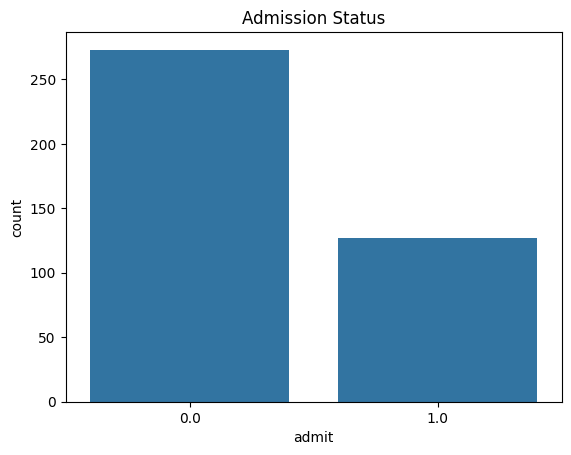

In [ ]:
sns.countplot(x="admit", data=df)

plt.title("Admission Status")

plt.show()

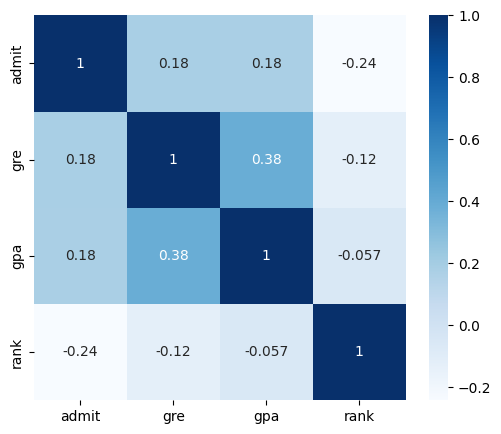

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(df.corr(),
            annot=True,
            cmap="Blues")

plt.show()

In [ ]:
X = df[['gre','gpa','rank']]

y = df['admit']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6625


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[51  2]
 [25  2]]


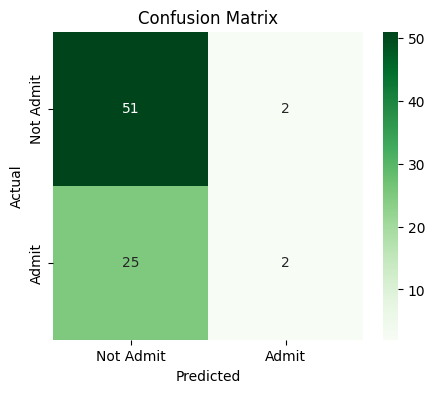

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Not Admit','Admit'],
            yticklabels=['Not Admit','Admit'])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.67      0.96      0.79        53
         1.0       0.50      0.07      0.13        27

    accuracy                           0.66        80
   macro avg       0.59      0.52      0.46        80
weighted avg       0.61      0.66      0.57        80



In [ ]:
new_student = pd.DataFrame({
    "gre": [700],
    "gpa": [3.8],
    "rank": [1]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Student is likely to be Admitted.")
else:
    print("Student is likely NOT to be Admitted.")

Student is likely to be Admitted.
